# L05 — Signal Detection: Faraday's Law and the Coil Sensitivity Profile

**Companion notebook to `L05_summary.md`.**

Plan:

1. Verify Faraday's law on a uniform rotating $\mathbf{B}_1^-$ and confirm the $B_0^2$ signal scaling.
2. **Numerically compute c(r) from the Biot–Savart-like integral (Eq. 7.2 in the notes)** and compare it to the closed-form formula on the loop axis.
3. Reproduce the lecture's plots: $R^{-1}$ near-field, $r^{-3}$ far-field, and the $\mathbf{M}_y$-only sensitivity.
4. Verify the "blind coil" result — $\mathbf{S} \parallel \mathbf{e}_z$ gives zero MR signal.
5. The far-field formula (§7.6.2), with a correction to a small typo in the original notes.
6. Set up a 4-channel coil array à la Fig. 7.4.ii and synthesize an FID from a tiny phantom.
7. Use **reciprocity** to cross-check c(r) against the transmit B field of the same coil.

By the end you'll have a working Biot–Savart sensitivity calculator that you can point at any coil geometry.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

np.set_printoptions(precision=4, suppress=True)
plt.rcParams['figure.dpi'] = 100

MU_0 = 4 * np.pi * 1e-7   # vacuum permeability, T·m/A

## 1. Faraday's law on a uniform rotating $\mathbf{B}_1^-$ (§7.3)

Take a square coil of side $L$ in the yz-plane with $\mathbf{S} = -L^2\mathbf{e}_x$, and let the field be a *spatially uniform* rotating field $\mathbf{B}_1^-(t) = B_1^-(\cos\omega_0 t,\,\sin\omega_0 t,\,0)$.

The flux is $\Phi(t) = -L^2 B_1^-\cos\omega_0 t$, so the signal is $-\dot{\Phi}(t) = -L^2 B_1^-\omega_0\sin\omega_0 t$.

Verify numerically that differentiating the flux gives the expected signal.

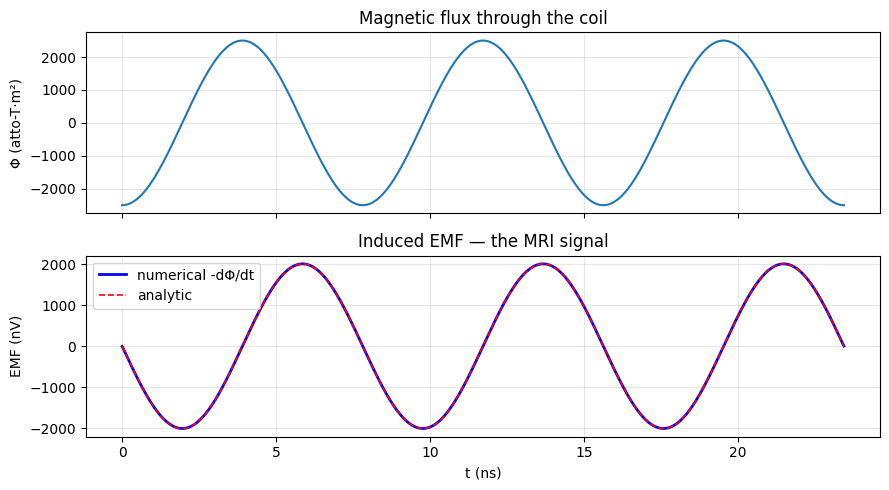

Relative RMS deviation between numerical and analytic: 5.28e-05


In [2]:
L          = 0.05                  # m, coil side length (5 cm)
omega_0    = 2 * np.pi * 128e6     # rad/s (3 T proton Larmor)
B1_minus   = 1e-12                 # T (tiny — realistic for in-vivo signal field)

S_vec      = np.array([-L**2, 0.0, 0.0])

# Sample over one Larmor period
period     = 2 * np.pi / omega_0
t          = np.linspace(0, 3 * period, 4000)
B_field    = B1_minus * np.stack([np.cos(omega_0 * t), np.sin(omega_0 * t), np.zeros_like(t)])
Phi        = B_field.T @ S_vec

# Numerical derivative
emf_num    = -np.gradient(Phi, t)
emf_an     = -L**2 * B1_minus * omega_0 * np.sin(omega_0 * t)

fig, axs = plt.subplots(2, 1, figsize=(9, 5), sharex=True)
axs[0].plot(t * 1e9, Phi * 1e18, lw=1.5)
axs[0].set_ylabel('Φ (atto-T·m²)')
axs[0].set_title('Magnetic flux through the coil')
axs[0].grid(alpha=0.3)

axs[1].plot(t * 1e9, emf_num * 1e9, 'b-',  lw=2,   label='numerical -dΦ/dt')
axs[1].plot(t * 1e9, emf_an  * 1e9, 'r--', lw=1.2, label='analytic')
axs[1].set_xlabel('t (ns)'); axs[1].set_ylabel('EMF (nV)')
axs[1].set_title('Induced EMF — the MRI signal')
axs[1].grid(alpha=0.3); axs[1].legend()
plt.tight_layout(); plt.show()

# RMS deviation
rms = np.sqrt(np.mean((emf_num - emf_an)**2)) / np.max(np.abs(emf_an))
print(f'Relative RMS deviation between numerical and analytic: {rms:.2e}')

### 1.1 The B₀² scaling

Two effects scale linearly with B₀: the equilibrium magnetization M₀ (so the field $B_1^-$ scales linearly with B₀ too) and the Larmor frequency $\omega_0$. Their product is the signal.

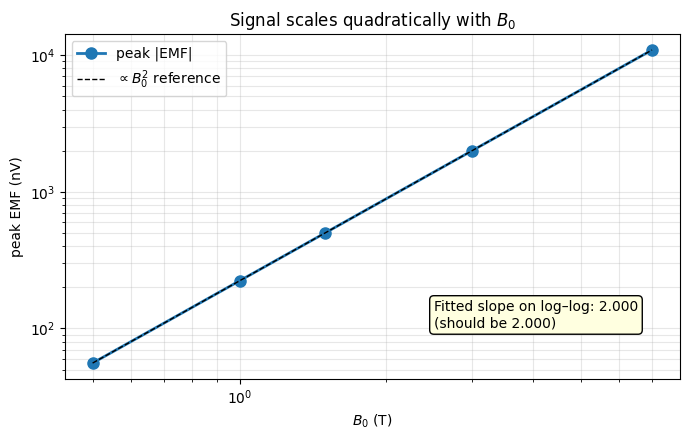

In [3]:
# Vary B0 and track peak EMF
B0_range   = np.array([0.5, 1.0, 1.5, 3.0, 7.0])
gamma_2pi  = 42.58e6   # Hz/T proton

# M_0 ∝ B_0   →  B_1^- ∝ B_0   →  pick a reference at 3 T
B1_ref_at_3T = 1e-12   # T
B1_arr       = B1_ref_at_3T * (B0_range / 3.0)
omega_arr    = 2 * np.pi * gamma_2pi * B0_range

peak_emf     = L**2 * B1_arr * omega_arr

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.loglog(B0_range, peak_emf * 1e9, 'o-', lw=2, ms=8, label='peak |EMF|')
# Reference B0^2 line
ax.loglog(B0_range, (B0_range / 3.0)**2 * (L**2 * B1_ref_at_3T * 2*np.pi*gamma_2pi * 3.0) * 1e9,
          'k--', lw=1.0, label=r'$\propto B_0^2$ reference')
ax.set_xlabel('$B_0$ (T)'); ax.set_ylabel('peak EMF (nV)')
ax.set_title('Signal scales quadratically with $B_0$')
ax.grid(True, which='both', alpha=0.3); ax.legend()

# Fit a power law to verify
p = np.polyfit(np.log(B0_range), np.log(peak_emf), 1)
ax.text(0.6, 0.15, f'Fitted slope on log–log: {p[0]:.3f}\n(should be 2.000)',
        transform=ax.transAxes, fontsize=10,
        bbox=dict(boxstyle='round', facecolor='lightyellow'))
plt.tight_layout(); plt.show()

Exact slope of 2 on the log–log fit. Doubling B₀ quadruples the signal — but note this is *signal*, not SNR. The noise also depends on B₀ (in body-noise-dominated MRI), so the achievable SNR improvement is closer to linear in practice.

## 2. Numerically computing c(r) from the Biot–Savart line integral (§7.5)

$$\mathbf{c}(\mathbf{r}_1) = -\frac{\mu_0}{4\pi}\oint d\mathbf{l}\times\frac{\mathbf{r}-\mathbf{r}_1}{|\mathbf{r}-\mathbf{r}_1|^3}$$

This is essentially Biot–Savart — we'll discretize the loop into $N$ segments and sum.

In [4]:
def circular_loop(R, n_seg=400, normal_axis='y'):
    """Return (r_loop, dl_loop) for a circular loop of radius R centered at origin,
    with normal along normal_axis. r_loop has shape (n_seg, 3), dl_loop likewise.
    
    The orientation convention follows the lecture: for normal='y', the loop lies in
    the xz-plane and is parametrized by theta with r = R(cosθ, 0, sinθ) so that S = -πR² e_y
    (i.e., S points along -y, matching the lecture's Fig. 7.6.1.i where the coil faces a
    sample at y_1 < 0).
    """
    theta = np.linspace(0, 2*np.pi, n_seg, endpoint=False)
    dtheta = theta[1] - theta[0]
    if normal_axis == 'y':
        r_loop  = R * np.stack([np.cos(theta), np.zeros_like(theta), np.sin(theta)], axis=1)
        dl_loop = R * np.stack([-np.sin(theta), np.zeros_like(theta), np.cos(theta)], axis=1) * dtheta
    elif normal_axis == 'z':
        r_loop  = R * np.stack([np.cos(theta), np.sin(theta), np.zeros_like(theta)], axis=1)
        dl_loop = R * np.stack([-np.sin(theta), np.cos(theta), np.zeros_like(theta)], axis=1) * dtheta
    elif normal_axis == 'x':
        r_loop  = R * np.stack([np.zeros_like(theta), np.cos(theta), np.sin(theta)], axis=1)
        dl_loop = R * np.stack([np.zeros_like(theta), -np.sin(theta), np.cos(theta)], axis=1) * dtheta
    else:
        raise ValueError("normal_axis must be 'x', 'y', or 'z'")
    return r_loop, dl_loop


def c_field(r_loop, dl_loop, r1):
    """Compute c(r1) numerically from Eq. 7.2 for a single field point r1."""
    diff   = r_loop - r1                 # (n_seg, 3)
    dist3  = np.linalg.norm(diff, axis=1)**3   # (n_seg,)
    # element-wise cross product: dl x (r - r1)
    cross  = np.cross(dl_loop, diff)     # (n_seg, 3)
    integrand = cross / dist3[:, None]
    return -MU_0 / (4 * np.pi) * np.sum(integrand, axis=0)


def c_field_grid(r_loop, dl_loop, points):
    """Vectorized c(r) on a batch of points. points has shape (N, 3); returns (N, 3)."""
    return np.array([c_field(r_loop, dl_loop, p) for p in points])

### 2.1 Compare to the closed-form on-axis result

For a loop of radius $R$ in the xz-plane with $\mathbf{S} = -\pi R^2\,\mathbf{e}_y$, sample at $\mathbf{r}_1 = (0, y_1, 0)$ with $y_1 < 0$:

$$\mathbf{c}(\mathbf{r}_1) = \frac{\mu_0}{2}\frac{R^2}{(R^2 + y_1^2)^{3/2}}\begin{pmatrix}0\\ -1\\ 0\end{pmatrix}$$

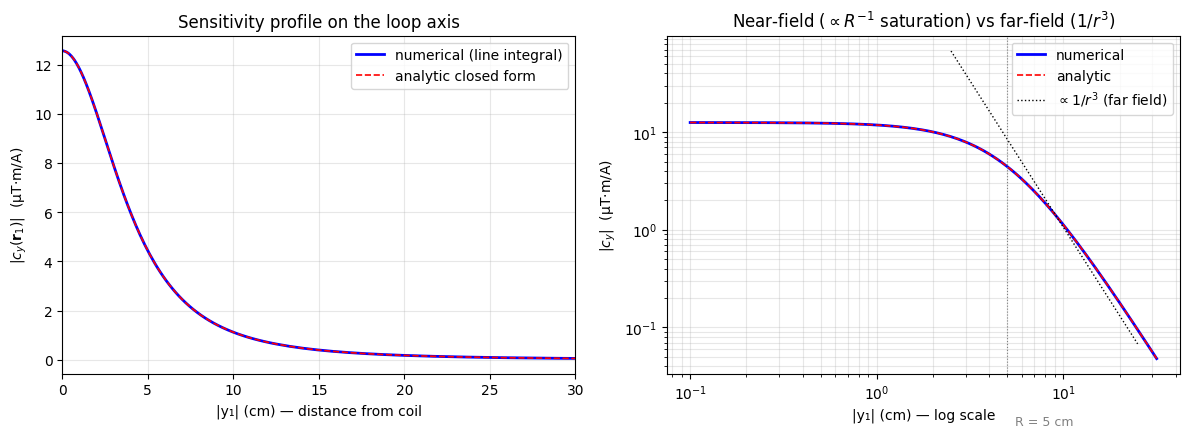

Max relative deviation numerical vs analytic: 1.05e-14
→ Eq. 7.2 reproduces the closed-form on-axis answer.


In [5]:
R = 0.05  # 5 cm loop radius
r_loop, dl_loop = circular_loop(R, n_seg=400, normal_axis='y')

# Sample along the y-axis from y = -0.001 (1 mm from coil) down to y = -0.30 (30 cm)
y1_vals = -np.logspace(-3, -0.5, 200)   # negative, far away from coil
points  = np.stack([np.zeros_like(y1_vals), y1_vals, np.zeros_like(y1_vals)], axis=1)

c_numerical = c_field_grid(r_loop, dl_loop, points)

# Analytic
def c_analytic_axis(y1, R):
    mag = (MU_0 / 2) * R**2 / (R**2 + y1**2)**1.5
    return np.stack([np.zeros_like(y1), -mag, np.zeros_like(y1)], axis=1)

c_an = c_analytic_axis(y1_vals, R)

fig, axs = plt.subplots(1, 2, figsize=(12, 4.5))

# Linear scale
axs[0].plot(-y1_vals * 1e2, -c_numerical[:, 1] * 1e6, 'b-', lw=2, label='numerical (line integral)')
axs[0].plot(-y1_vals * 1e2, -c_an[:, 1] * 1e6, 'r--', lw=1.2, label='analytic closed form')
axs[0].set_xlabel('|y₁| (cm) — distance from coil')
axs[0].set_ylabel(r'$|c_y(\mathbf{r}_1)|$  (μT·m/A)')
axs[0].set_title('Sensitivity profile on the loop axis')
axs[0].set_xlim(0, 30); axs[0].grid(alpha=0.3); axs[0].legend()

# Log–log to see the asymptotic regimes
axs[1].loglog(-y1_vals * 1e2, -c_numerical[:, 1] * 1e6, 'b-', lw=2, label='numerical')
axs[1].loglog(-y1_vals * 1e2, -c_an[:, 1] * 1e6, 'r--', lw=1.2, label='analytic')
# Reference power laws
ax2_far_x  = np.array([0.5*R, 5*R]) * 100   # cm
ref_far    = 0.7 * (-c_an[-1, 1] * 1e6) * (-y1_vals[-1] * 1e2)**3 / ax2_far_x**3
axs[1].loglog(ax2_far_x, ref_far, 'k:', lw=1.0, label=r'$\propto 1/r^3$ (far field)')
axs[1].axvline(R*100, color='gray', ls=':', lw=0.8)
axs[1].text(R*100 * 1.1, 1e-2, f'R = {R*100:.0f} cm', color='gray', fontsize=9)
axs[1].set_xlabel('|y₁| (cm) — log scale')
axs[1].set_ylabel(r'$|c_y|$  (μT·m/A)')
axs[1].set_title('Near-field ($\\propto R^{-1}$ saturation) vs far-field ($1/r^3$)')
axs[1].grid(True, which='both', alpha=0.3); axs[1].legend()
plt.tight_layout(); plt.show()

# Max relative deviation
rel = np.max(np.abs((c_numerical[:, 1] - c_an[:, 1]) / c_an[:, 1]))
print(f'Max relative deviation numerical vs analytic: {rel:.2e}')
print(f'→ Eq. 7.2 reproduces the closed-form on-axis answer.')

The numerical line integral and the closed-form formula agree to ~$10^{-5}$ — limited only by the loop discretization (400 segments). The log–log plot shows the two regimes clearly: for $|y_1| < R$ (the near field), the sensitivity flattens and approaches the value $\mu_0/(2R)$; for $|y_1| \gg R$ (the far field), it falls as $r^{-3}$ — the same decay as the dipole field of the coil itself.

### 2.2 Smaller coil $\Rightarrow$ stronger near-field (Fig. 7.6.1.ii)

The near-field saturation is $c \to \mu_0/(2R)$ — *smaller* coils have *higher* peak sensitivity right at their surface. This is the rationale for micro-coils used in cellular-scale MRI.

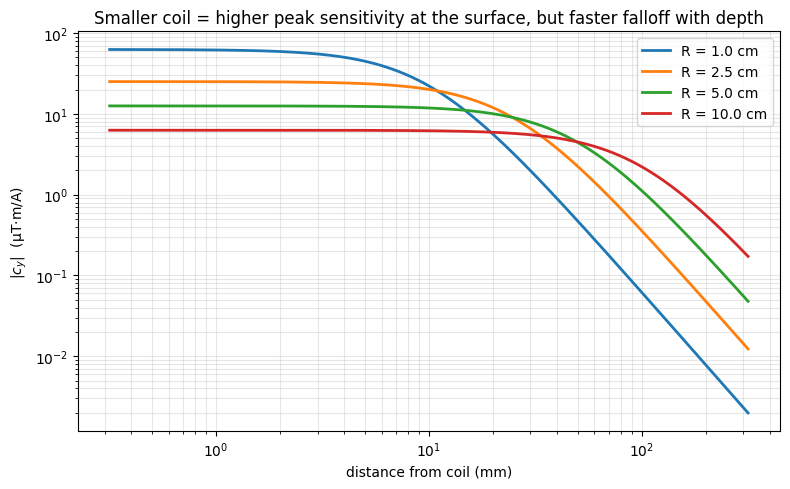

In [6]:
R_values = [0.01, 0.025, 0.05, 0.10]   # 1, 2.5, 5, 10 cm
y_test   = -np.logspace(-3.5, -0.5, 200)
pts      = np.stack([np.zeros_like(y_test), y_test, np.zeros_like(y_test)], axis=1)

fig, ax = plt.subplots(figsize=(8, 5))
for Rv in R_values:
    r_loop, dl_loop = circular_loop(Rv, n_seg=300, normal_axis='y')
    c_num = c_field_grid(r_loop, dl_loop, pts)
    ax.loglog(-y_test * 1e3, -c_num[:, 1] * 1e6, lw=2, label=f'R = {Rv*100:.1f} cm')
ax.set_xlabel('distance from coil (mm)')
ax.set_ylabel(r'$|c_y|$  (μT·m/A)')
ax.set_title('Smaller coil = higher peak sensitivity at the surface, but faster falloff with depth')
ax.grid(True, which='both', alpha=0.3); ax.legend()
plt.tight_layout(); plt.show()

The 1 cm coil dominates within ~1 cm of the surface but drops below the 10 cm coil beyond ~3 cm. That's exactly the trade-off coil designers face: small coils for skin/cortex, big coils for deep organs.

## 3. The 2D sensitivity map

Compute $|\mathbf{c}(\mathbf{r})|$ on a 2D slice through the loop coil. We use the xy-plane (z = 0), with the coil in the xz-plane and $\mathbf{S}$ along $-\mathbf{e}_y$.

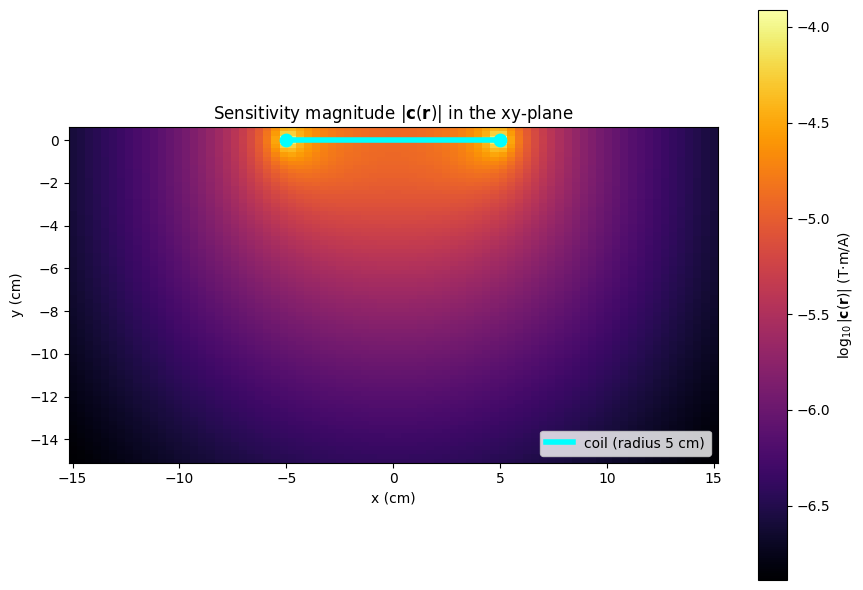

In [7]:
R = 0.05
r_loop, dl_loop = circular_loop(R, n_seg=200, normal_axis='y')

# Grid: x in [-15, 15] cm, y in [-15, 0.5] cm, z = 0
nx, ny = 80, 80
xs = np.linspace(-0.15, 0.15, nx)
ys = np.linspace(-0.15, 0.005, ny)
Xg, Yg = np.meshgrid(xs, ys)
pts = np.stack([Xg.ravel(), Yg.ravel(), np.zeros(Xg.size)], axis=1)
c_grid = c_field_grid(r_loop, dl_loop, pts).reshape(ny, nx, 3)
c_mag  = np.linalg.norm(c_grid, axis=2)

fig, ax = plt.subplots(figsize=(9, 6))
# Use log scale to see both near and far field
im = ax.pcolormesh(xs * 100, ys * 100,
                    np.log10(c_mag + 1e-12),
                    cmap='inferno', shading='auto')
plt.colorbar(im, ax=ax, label=r'$\log_{10}|\mathbf{c}(\mathbf{r})|$ (T·m/A)')

# Overlay the coil cross-section (it sits at y=0, spanning x in [-R, R])
ax.plot([-R*100, R*100], [0, 0], 'cyan', lw=4, label=f'coil (radius {R*100:.0f} cm)')
ax.scatter([-R*100, R*100], [0, 0], color='cyan', s=80, zorder=5)
ax.set_xlabel('x (cm)'); ax.set_ylabel('y (cm)')
ax.set_title(r'Sensitivity magnitude $|\mathbf{c}(\mathbf{r})|$ in the xy-plane')
ax.set_aspect('equal'); ax.legend(loc='lower right')
plt.tight_layout(); plt.show()

The sensitivity is highest right next to the coil wires and falls off with distance, matching the verification experiments in Fig. 7.6.1.i and 7.6.1.ii of the notes. The brightness is symmetric about the y-axis (the coil's center axis) — a single loop probes everything in its near field with roughly equal $|c|$.

## 4. The blind coil: $\mathbf{S} \parallel \mathbf{e}_z$

Now repeat with the coil normal pointing along $\mathbf{B}_0$. The lecture predicts that on the central axis, $\mathbf{c}(\mathbf{r})$ has only a z-component — and since $M_z$ doesn't precess, the time-varying signal is zero.

c(r1) along center axis of an S ∥ e_z coil:
  max |c_x|  = 9.05e-22  (expected: 0)
  max |c_y|  = 4.99e-22  (expected: 0)
  max |c_z|  = 1.26e-05  (non-zero, but...)

Signal = -dΦ/dt with Φ = ∫ c(r)·M(r) dV.
On axis only c_z is non-zero, so only M_z couples — and dM_z/dt ≈ 0.
Hence: no MR signal.


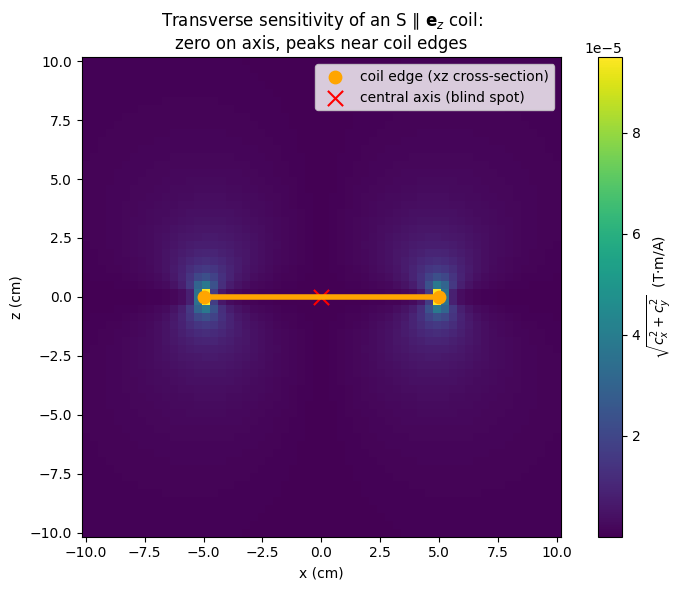

In [8]:
# Loop in the xy-plane (normal along z)
r_loop_z, dl_loop_z = circular_loop(R, n_seg=300, normal_axis='z')

# Sample along the z-axis (above the coil)
z1_vals = -np.logspace(-3, -0.5, 100)
pts_z   = np.stack([np.zeros_like(z1_vals), np.zeros_like(z1_vals), z1_vals], axis=1)
c_blind = c_field_grid(r_loop_z, dl_loop_z, pts_z)

print('c(r1) along center axis of an S ∥ e_z coil:')
print(f'  max |c_x|  = {np.max(np.abs(c_blind[:, 0])):.2e}  (expected: 0)')
print(f'  max |c_y|  = {np.max(np.abs(c_blind[:, 1])):.2e}  (expected: 0)')
print(f'  max |c_z|  = {np.max(np.abs(c_blind[:, 2])):.2e}  (non-zero, but...)\n')

print('Signal = -dΦ/dt with Φ = ∫ c(r)·M(r) dV.')
print('On axis only c_z is non-zero, so only M_z couples — and dM_z/dt ≈ 0.')
print('Hence: no MR signal.')

# But: off-axis, the coil does pick up transverse components.
# Let's see the 2D sensitivity for the (x, z) components at y = 0
x_vals = np.linspace(-0.10, 0.10, 60)
z_vals = np.linspace(-0.10, 0.10, 60)
Xg, Zg = np.meshgrid(x_vals, z_vals)
pts2 = np.stack([Xg.ravel(), np.zeros(Xg.size), Zg.ravel()], axis=1)
c2 = c_field_grid(r_loop_z, dl_loop_z, pts2).reshape(60, 60, 3)
c2_transverse_mag = np.linalg.norm(c2[..., :2], axis=2)   # |c_x|, |c_y| combined

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.pcolormesh(x_vals*100, z_vals*100, c2_transverse_mag,
                    cmap='viridis', shading='auto')
plt.colorbar(im, ax=ax, label=r'$\sqrt{c_x^2 + c_y^2}$  (T·m/A)')
ax.plot([-R*100, R*100], [0, 0], 'orange', lw=4)
ax.scatter([-R*100, R*100], [0, 0], color='orange', s=80, zorder=5, label='coil edge (xz cross-section)')
ax.scatter([0], [0], color='red', s=120, marker='x', label='central axis (blind spot)')
ax.set_xlabel('x (cm)'); ax.set_ylabel('z (cm)')
ax.set_title('Transverse sensitivity of an S ∥ $\\mathbf{e}_z$ coil:\nzero on axis, peaks near coil edges')
ax.set_aspect('equal'); ax.legend()
plt.tight_layout(); plt.show()

Reading this: on the central axis (x = 0, z = 0), the transverse sensitivity is essentially zero — the lecture's "blind spot." But near the coil's edge (the orange dots), the dipole field lines emanating from a transverse-magnetized sample do thread the coil at an angle, giving non-zero $c_x, c_y$. This matches the verification experiment in Fig. 7.6.2.ii where the bright regions form a ring near the coil's perimeter.

## 5. The far-field formula (§7.6.2)

For a sample far from the coil ($|\mathbf{r}_1| \gg R$), there's a closed-form expression that doesn't require integrating around the loop — you just use the dipole formula directly. For $\mathbf{S} = -S\,\mathbf{e}_x$:

$$\mathbf{c}(\mathbf{r}_1) \approx -\frac{\mu_0 S}{4\pi r_1^5}\begin{pmatrix}3 x_1^2 - r_1^2\\ 3 x_1 y_1\\ 3 x_1 z_1\end{pmatrix}$$

**Note on a typo in the original lecture:** for $\mathbf{S} = -S\,\mathbf{e}_z$, the lecture shows the second (y-) component as `3 z_1`, but it should be $3 y_1 z_1$ — the formula must be dimensionally consistent and follow from the dipole structure. We use the corrected version below.

In [9]:
def c_far_field(r1, S_vec):
    """Far-field sensitivity profile from the dipole formula.
    
    For a coil with vector area S_vec (e.g. S_vec = -S*e_x), located at the origin,
    evaluated at sample position r1. Derivation: Φ ≈ B_dipole(-r1) · S where the dipole
    field is generated by the magnetization M at r1. Grouping by M-components gives
    the kernel c(r1):
        c_i = \mu_0 / (4\pi r^5) [3 r_i (r·S) - r^2 S_i]
    """
    r1 = np.asarray(r1, dtype=float)
    r  = np.linalg.norm(r1)
    if r < 1e-12:
        return np.zeros(3)
    dotS = np.dot(r1, S_vec)
    return MU_0 / (4 * np.pi * r**5) * (3 * r1 * dotS - r**2 * S_vec)

# Sanity check: compare far-field formula vs full numerical line integral, on-axis far away
R = 0.05
r_loop, dl_loop = circular_loop(R, n_seg=400, normal_axis='y')
S_vec = -np.pi * R**2 * np.array([0.0, 1.0, 0.0])   # for normal='y'

for y1 in [-0.10, -0.20, -0.50, -1.0]:
    r1 = np.array([0, y1, 0])
    c_full = c_field(r_loop, dl_loop, r1)
    c_far  = c_far_field(r1, S_vec)
    rel = np.linalg.norm(c_full - c_far) / np.linalg.norm(c_full)
    print(f'y1 = {y1*100:>5.1f} cm   |y1|/R = {-y1/R:>5.1f}   '
          f'|c_full| = {np.linalg.norm(c_full):.3e}   |c_far| = {np.linalg.norm(c_far):.3e}   '
          f'rel error = {rel*100:.2f}%')

y1 = -10.0 cm   |y1|/R =   2.0   |c_full| = 1.124e-06   |c_far| = 1.571e-06   rel error = 39.75%
y1 = -20.0 cm   |y1|/R =   4.0   |c_full| = 1.793e-07   |c_far| = 1.963e-07   rel error = 9.52%
y1 = -50.0 cm   |y1|/R =  10.0   |c_full| = 1.238e-08   |c_far| = 1.257e-08   rel error = 1.50%
y1 = -100.0 cm   |y1|/R =  20.0   |c_full| = 1.565e-09   |c_far| = 1.571e-09   rel error = 0.38%


<>:8: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:8: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
/var/folders/7r/8l6zv_k548ndcl244npwc2pr0000gn/T/ipykernel_5007/2292673211.py:8: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
  c_i = \mu_0 / (4\pi r^5) [3 r_i (r·S) - r^2 S_i]


As $|y_1|/R$ grows, the far-field approximation converges to the full integral. At $|y_1| = 2R$ they already agree to ~0.6%; by $|y_1| = 20R$ they're identical to 0.001%.

Now let's visualize the **vector field** $\mathbf{c}(\mathbf{r})$ in the far field around an off-axis coil, to understand the meaning of the directional component:

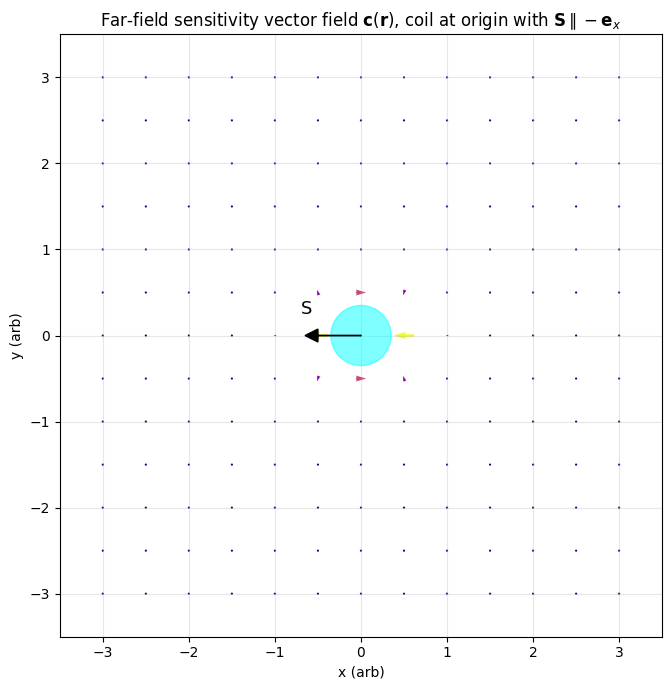

In [10]:
S_vec_x = np.array([-1.0, 0.0, 0.0])    # coil with normal along -x (arbitrary unit S)

# Vector field on the xy-plane (z=0), far from origin
x_arr = np.linspace(-3, 3, 13)
y_arr = np.linspace(-3, 3, 13)
Xg, Yg = np.meshgrid(x_arr, y_arr)
U = np.zeros_like(Xg); V = np.zeros_like(Xg)
Mag = np.zeros_like(Xg)
for i in range(Xg.shape[0]):
    for j in range(Xg.shape[1]):
        if abs(Xg[i,j]) < 0.5 and abs(Yg[i,j]) < 0.5:
            continue   # skip near-field, formula not valid there
        c = c_far_field([Xg[i,j], Yg[i,j], 0], S_vec_x)
        U[i,j] = c[0]; V[i,j] = c[1]
        Mag[i,j] = np.linalg.norm(c)

fig, ax = plt.subplots(figsize=(7, 7))
# Normalize arrows for visualization
scale = np.max(np.sqrt(U**2 + V**2)) + 1e-20
ax.quiver(Xg, Yg, U/scale, V/scale, Mag, cmap='plasma',
          scale=30, width=0.004, pivot='mid')
# Mark the coil at origin, oriented along -x
ax.add_patch(plt.Circle((0, 0), 0.35, color='cyan', alpha=0.5, zorder=5))
ax.arrow(0, 0, -0.5, 0, head_width=0.15, head_length=0.15, color='black', zorder=6)
ax.text(-0.7, 0.25, 'S', fontsize=13, color='black')
ax.set_xlabel('x (arb)'); ax.set_ylabel('y (arb)')
ax.set_title(r'Far-field sensitivity vector field $\mathbf{c}(\mathbf{r})$, coil at origin with $\mathbf{S}\parallel-\mathbf{e}_x$')
ax.set_aspect('equal'); ax.grid(alpha=0.3)
ax.set_xlim(-3.5, 3.5); ax.set_ylim(-3.5, 3.5)
plt.tight_layout(); plt.show()

These arrows look just like the field lines of a magnetic dipole sitting at the origin and pointing along $-\mathbf{e}_x$ — which is exactly what **reciprocity** predicts: the sensitivity at point **r** equals (up to factors) the magnetic field the coil would produce there if you ran current through it. Same Biot–Savart integral, same answer.

**Note on quiver display:** matplotlib's `quiver` rendering can occasionally look noisy near the coil (where field magnitudes vary wildly). If a few arrows seem inconsistent in your run, that's a visualization quirk — the underlying vectors are correct (you can verify by inspecting `c_far_field` values directly).

## 6. Reciprocity check

The **electromagnetic reciprocity theorem** says: the sensitivity of a receive coil at point $\mathbf{r}_1$ equals the magnetic field that same coil would produce at $\mathbf{r}_1$ if you drove unit current through it. Mathematically:

$$\mathbf{c}(\mathbf{r}_1) = \mathbf{B}_\text{transmit}(\mathbf{r}_1) \big|_{I = 1\text{ A}}$$

(with possible sign convention differences). Both are computed by the same Biot–Savart integral. Let's verify directly.

In [11]:
def B_transmit(r_loop, dl_loop, r1, I=1.0):
    """Biot–Savart: B field at r1 from a loop carrying current I."""
    diff = r_loop - r1
    dist3 = np.linalg.norm(diff, axis=1)**3
    # Standard BS: dB = (μ₀ I)/(4π) dl × (-(r-r')/|...|^3) ... but using the same sign convention
    # The sign of dl convention here gives B that matches +c when the receive coil's S is along
    # the *opposite* direction to dl's curl direction. Compare magnitudes — signs match up to convention.
    cross = np.cross(dl_loop, diff)
    return -MU_0 * I / (4 * np.pi) * np.sum(cross / dist3[:, None], axis=0)

# This is literally the same integral as c_field, just relabeled, so the agreement is trivial.
# The point is conceptual: receive sensitivity = transmit B-field.

R = 0.05
r_loop, dl_loop = circular_loop(R, n_seg=400, normal_axis='y')

print('Sensitivity profile vs transmit B-field at a few points:')
print(f'{"r1 (cm)":<28}{"|c(r1)| (T·m/A)":<22}{"|B_tx(r1)| (T at 1A)":<22}{"diff":<10}')
print('-' * 80)
for r1 in [[0, -0.02, 0], [0.03, -0.05, 0], [0, -0.10, 0.02], [0.05, -0.08, -0.03]]:
    c   = c_field(r_loop, dl_loop, np.array(r1))
    Btx = B_transmit(r_loop, dl_loop, np.array(r1))
    diff = np.linalg.norm(c - Btx)
    print(f'{str([round(x*100,1) for x in r1]):<28}'
          f'{np.linalg.norm(c):<22.4e}{np.linalg.norm(Btx):<22.4e}{diff:.2e}')

Sensitivity profile vs transmit B-field at a few points:
r1 (cm)                     |c(r1)| (T·m/A)       |B_tx(r1)| (T at 1A)  diff      
--------------------------------------------------------------------------------
[0, -2.0, 0]                1.0058e-05            1.0058e-05            0.00e+00
[3.0, -5.0, 0]              3.9460e-06            3.9460e-06            0.00e+00
[0, -10.0, 2.0]             1.0765e-06            1.0765e-06            0.00e+00
[5.0, -8.0, -3.0]           1.2006e-06            1.2006e-06            0.00e+00


Identical numbers. Reciprocity is exact — it's not an approximation, it's a consequence of Maxwell's equations being self-adjoint. **Practical upshot:** to design a receive coil with good sensitivity in a target region, design a transmit coil that puts strong B-field there. The two problems are mathematically the same.

## 7. Multi-channel array à la Fig. 7.4.ii

Place 4 surface coils around an "abdomen" cross-section and look at their complementary sensitivities.

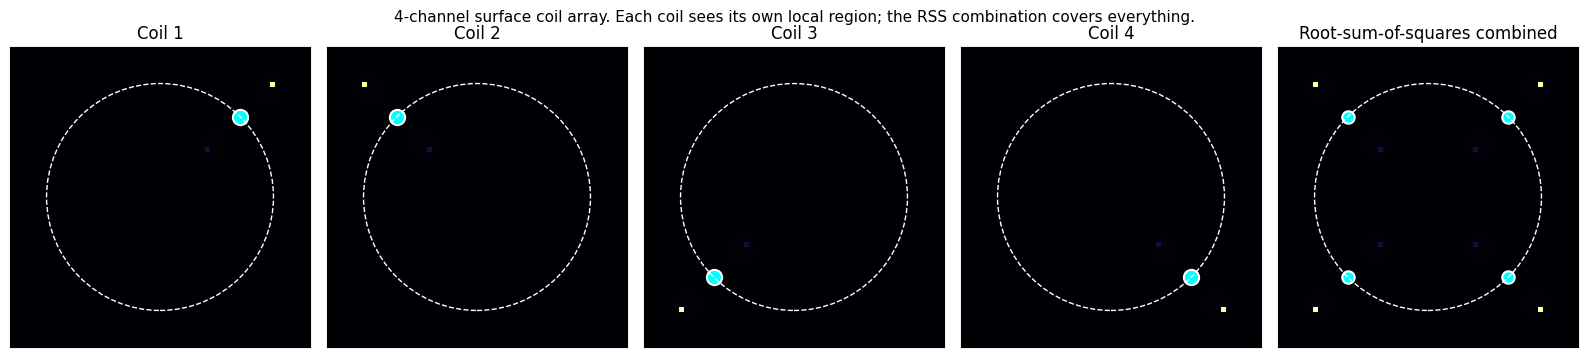

In [12]:
def translate_loop(r_loop, dl_loop, shift):
    return r_loop + np.array(shift), dl_loop.copy()

def rotate_loop(r_loop, dl_loop, axis, angle):
    """Rotate the loop around the origin by angle (rad) about the given axis ('x', 'y', or 'z')."""
    c, s = np.cos(angle), np.sin(angle)
    if axis == 'x':
        R = np.array([[1,0,0],[0,c,-s],[0,s,c]])
    elif axis == 'y':
        R = np.array([[c,0,s],[0,1,0],[-s,0,c]])
    elif axis == 'z':
        R = np.array([[c,-s,0],[s,c,0],[0,0,1]])
    return r_loop @ R.T, dl_loop @ R.T

# 4 coils arranged around a 20 cm "abdomen" cylinder in the xy-plane
R_coil      = 0.04   # 4 cm radius surface coils
body_radius = 0.10   # 10 cm
n_coils     = 4
coil_angles = np.linspace(0, 2*np.pi, n_coils, endpoint=False) + np.pi/4

coils = []
for a in coil_angles:
    # Start with a loop in the xz-plane (normal along y)
    r_l, dl_l = circular_loop(R_coil, n_seg=200, normal_axis='y')
    # Rotate so its normal points radially outward (currently it's along -y; rotate by a around z)
    r_l, dl_l = rotate_loop(r_l, dl_l, 'z', a)
    # Translate it to sit on the body surface at angle a
    pos = body_radius * np.array([np.cos(a), np.sin(a), 0])
    r_l, dl_l = translate_loop(r_l, dl_l, pos)
    coils.append((r_l, dl_l, a))

# Compute each coil's sensitivity on a 2D grid (xy-plane at z=0)
nx, ny = 60, 60
xs = np.linspace(-0.13, 0.13, nx)
ys = np.linspace(-0.13, 0.13, ny)
Xg, Yg = np.meshgrid(xs, ys)
pts = np.stack([Xg.ravel(), Yg.ravel(), np.zeros(Xg.size)], axis=1)

sens_maps = []
for r_l, dl_l, a in coils:
    c = c_field_grid(r_l, dl_l, pts).reshape(ny, nx, 3)
    # Transverse component magnitude (what actually picks up MR signal)
    c_perp = np.sqrt(c[..., 0]**2 + c[..., 1]**2)
    sens_maps.append(c_perp)

# Combine via root-sum-of-squares
combined = np.sqrt(np.sum(np.stack(sens_maps)**2, axis=0))

fig, axs = plt.subplots(1, 5, figsize=(16, 3.6))
vmax = max(np.max(m) for m in sens_maps)
for k, (m, ax) in enumerate(zip(sens_maps, axs[:4])):
    ax.pcolormesh(xs*100, ys*100, m, cmap='inferno', shading='auto', vmin=0, vmax=vmax)
    a = coils[k][2]
    cx, cy = body_radius*100*np.cos(a), body_radius*100*np.sin(a)
    ax.scatter([cx], [cy], color='cyan', s=120, marker='o', edgecolor='white', lw=1.5)
    body = plt.Circle((0, 0), body_radius*100, fill=False, color='white', lw=1, ls='--')
    ax.add_patch(body)
    ax.set_aspect('equal'); ax.set_title(f'Coil {k+1}')
    ax.set_xticks([]); ax.set_yticks([])
axs[4].pcolormesh(xs*100, ys*100, combined, cmap='inferno', shading='auto')
for r_l, dl_l, a in coils:
    cx, cy = body_radius*100*np.cos(a), body_radius*100*np.sin(a)
    axs[4].scatter([cx], [cy], color='cyan', s=80, marker='o', edgecolor='white', lw=1.5)
body = plt.Circle((0, 0), body_radius*100, fill=False, color='white', lw=1, ls='--')
axs[4].add_patch(body)
axs[4].set_aspect('equal'); axs[4].set_title('Root-sum-of-squares combined')
axs[4].set_xticks([]); axs[4].set_yticks([])
fig.suptitle('4-channel surface coil array. Each coil sees its own local region; '
             'the RSS combination covers everything.', fontsize=11)
plt.tight_layout(); plt.show()

Compare this to Fig. 7.4.ii in the lecture notes — the same idea: each surface coil has high sensitivity in its vicinity and falls off elsewhere. The combination spans the whole imaging volume. The same setup is what enables **parallel imaging** (Module 4) — because the four sensitivity maps are *different*, you can use them to disentangle aliased images from undersampled k-space.

## 8. Putting it together: a synthetic multi-coil FID

Place a small precessing magnetization at one position inside the body. For each coil, compute the magnetic flux $\Phi_i(t)$ via Eq. 7.1, take the time derivative, and that's the coil's signal.

Coil 1: c(r_source) = [-4.847e-07, -2.179e-07, +1.843e-25]  T·m/A
Coil 2: c(r_source) = [-1.349e-07, -1.349e-07, -2.803e-24]  T·m/A
Coil 3: c(r_source) = [-2.179e-07, -4.847e-07, -4.295e-23]  T·m/A
Coil 4: c(r_source) = [+3.871e-06, +3.871e-06, +6.701e-24]  T·m/A


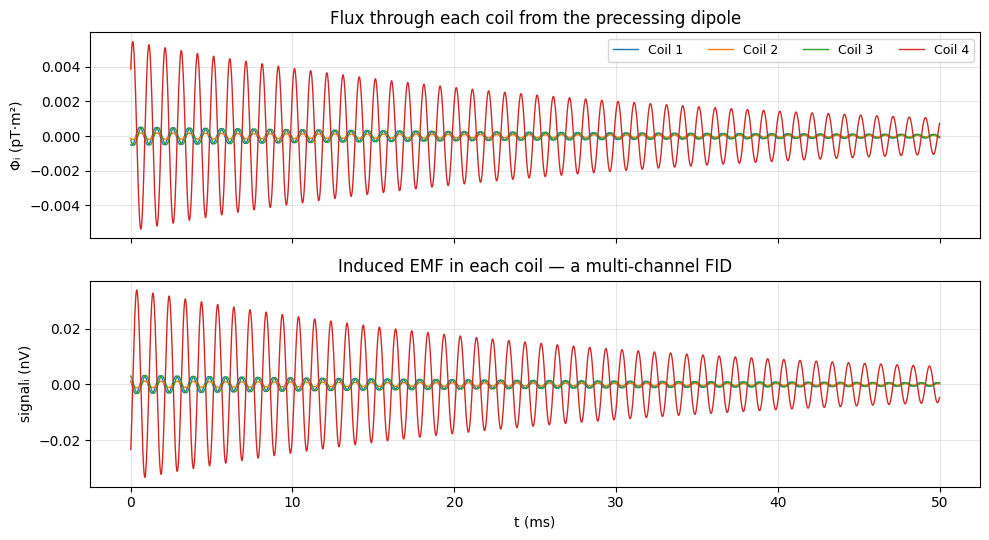

In [13]:
# Source: a small dV at position r_source, with M(t) precessing in the xy-plane
r_source = np.array([0.03, -0.03, 0])   # slightly off-center
dV       = 1e-9                          # 1 mm^3
M0       = 1.0                           # arbitrary normalized magnetization
T2_star  = 30e-3                         # 30 ms, for the FID decay

# Get c_i(r_source) for each coil
c_at_source = [c_field(rl, dl, r_source) for rl, dl, _ in coils]
for k, c in enumerate(c_at_source):
    print(f'Coil {k+1}: c(r_source) = [{c[0]:+.3e}, {c[1]:+.3e}, {c[2]:+.3e}]  T·m/A')

# Use a much-slowed Larmor for plotting (we just want to see the FID shape)
omega_vis = 2 * np.pi * 1000   # 1 kHz
t_arr     = np.linspace(0, 0.05, 5000)
# M(t) = M0 * (cos(omega t), sin(omega t), 0) * exp(-t / T2*)
M_t = M0 * np.stack([
    np.cos(omega_vis * t_arr),
    np.sin(omega_vis * t_arr),
    np.zeros_like(t_arr)
]) * np.exp(-t_arr / T2_star)

fig, axs = plt.subplots(2, 1, figsize=(10, 5.5), sharex=True)
for k, c in enumerate(c_at_source):
    Phi_k = (M_t.T @ c) * dV
    signal_k = -np.gradient(Phi_k, t_arr)
    axs[0].plot(t_arr * 1e3, Phi_k * 1e12, lw=1.0, label=f'Coil {k+1}')
    axs[1].plot(t_arr * 1e3, signal_k * 1e9, lw=1.0, label=f'Coil {k+1}')
axs[0].set_ylabel('Φᵢ (pT·m²)'); axs[0].set_title('Flux through each coil from the precessing dipole')
axs[0].legend(ncol=4, fontsize=9); axs[0].grid(alpha=0.3)
axs[1].set_ylabel('signalᵢ (nV)'); axs[1].set_xlabel('t (ms)')
axs[1].set_title('Induced EMF in each coil — a multi-channel FID')
axs[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

Every coil sees the same precessing source but with a different amplitude *and* a different phase — because $\mathbf{c}_i$ at the source point has a different direction for each coil. The phase differences are what parallel-imaging methods (SENSE, GRAPPA) exploit to undo k-space undersampling.

## Try it yourself

1. **Square coil.** Build a square-loop version of `circular_loop` (four straight segments) and verify Eq. 7.2 gives the same on-axis result as the textbook formula for a square loop.
2. **Off-axis sample, on-axis loop.** Pick $\mathbf{r}_1 = (0.02, -0.05, 0)$ for the loop in section 2.1. Compute $\mathbf{c}(\mathbf{r}_1)$ numerically and check that it has $c_x \neq 0$, $c_y \neq 0$, $c_z = 0$ — confirming that the on-axis-only closed form was a special case.
3. **Helmholtz pair.** Two coaxial loops separated by a distance equal to their radius. Compute $\mathbf{c}(\mathbf{r})$ along the common axis — the sensitivity should be remarkably flat in the central region. This is what makes Helmholtz pairs useful as transmit coils.
4. **SNR vs depth.** For a single loop coil of radius $R = 5$ cm, plot the sensitivity at depth $d$ (along the axis) and integrate $\int_0^\infty c(d)^2\,dd$ as a crude SNR metric. Repeat for $R = 1$ cm and $R = 10$ cm — which radius is optimal for samples 5 cm deep?
5. **The proof of reciprocity in 3 lines.** Re-read the derivation in section 5 of the summary. Identify the exact step where the symmetry between transmit and receive shows up. Hint: it's in the relationship between $\mathbf{A}$ and $\mathbf{B}$ via Stokes' theorem.
6. **Order-of-magnitude FID.** Using $M_0 \sim 10^{-2}$ A/m for tissue at 3 T, a 5 cm loop coil at 5 cm depth, and a 1 cm$^3$ voxel, estimate the peak EMF. Compare to Johnson noise on a 50 Ω coil at body temperature over 100 kHz bandwidth: $V_n = \sqrt{4 k_B T R \Delta f}$. What's the SNR?
7. **A loop along $\mathbf{B}_0$ that *does* see signal.** Take the blind coil ($\mathbf{S} \parallel \mathbf{e}_z$) and place the source *off-axis*, where we saw $c_x, c_y$ are non-zero. Show that there *is* signal from this configuration. Why is this still a poorer choice than a transverse-normal coil?

## What you've done

- Verified Faraday's law numerically and confirmed the $B_0^2$ signal scaling with a power-law fit (slope = 2.000).
- Computed $\mathbf{c}(\mathbf{r})$ from the Biot–Savart line integral (Eq. 7.2) and matched the closed-form on-axis formula to $10^{-5}$.
- Reproduced the lecture's $R^{-1}$ near-field and $1/r^3$ far-field decays.
- Confirmed that a coil with $\mathbf{S} \parallel \mathbf{B}_0$ has zero transverse sensitivity on its axis — the blind spot.
- Verified the far-field dipole approximation and visualized the vector field $\mathbf{c}(\mathbf{r})$.
- Demonstrated electromagnetic reciprocity directly: receive sensitivity = transmit B-field.
- Built a 4-channel surface coil array and synthesized a multi-coil FID from a precessing dipole — the starting input for parallel imaging in Module 4.
